Total parameter combinations: 144
Total iterations (parameter combinations × CV folds): 1440
Starting Grid Search...
Fitting 10 folds for each of 144 candidates, totalling 1440 fits


/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
480 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/h_wu4/ml_env/lib/python3.8/site-packages/imblearn/pipeline.py", line 333, in fit
    self._final_estimator.fit(Xt, yt, **last_step_params["

Grid Search Completed.

Best Average AUC: 0.7703 ± 0.0217
Average Accuracy: 0.8296 ± 0.0142
Average Precision: 0.2396 ± 0.0299
Average F1 Score: 0.2973 ± 0.0339

Best Hyperparameters:
  ada__algorithm: SAMME
  ada__estimator__max_depth: 17
  ada__estimator__max_features: sqrt
  ada__estimator__min_samples_leaf: 2
  ada__estimator__min_samples_split: 2
  ada__learning_rate: 0.001
  ada__n_estimators: 350
  sampler: ADASYN()
  sampler__sampling_strategy: 0.5

Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.3190, Accuracy=0.7447, Precision=0.2114
  Fold 2: F1=0.3128, Accuracy=0.8010, Precision=0.2276
  Fold 3: F1=0.2913, Accuracy=0.7638, Precision=0.2000
  Fold 4: F1=0.3200, Accuracy=0.7799, Precision=0.2222
  Fold 5: F1=0.3062, Accuracy=0.7654, Precision=0.2092
  Fold 6: F1=0.2900, Accuracy=0.7702, Precision=0.2014
  Fold 7: F1=0.3143, Accuracy=0.7670, Precision

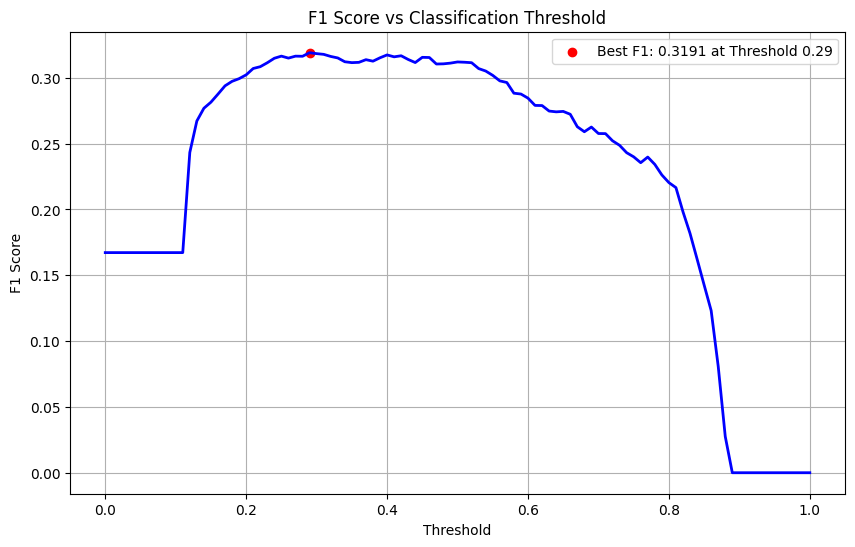

In [1]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress UndefinedMetricWarning and FutureWarning globally
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score, make_scorer
from imblearn.pipeline import Pipeline  # Use imblearn's Pipeline
import matplotlib.pyplot as plt
from math import prod

# Import oversampling techniques
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class1_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [24, 20, 16, 15, 12, 3, 10, 13, 21, 9, 22, 28, 29, 19, 38, 2, 6, 26, 31]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Initialize the base estimator for AdaBoost
estimator = DecisionTreeClassifier(random_state=42)

# Create a Pipeline with oversampling and AdaBoost
pipeline = Pipeline([
    ('sampler', RandomOverSampler()),  # Initialize with a default oversampler
    ('ada', AdaBoostClassifier(random_state=42, estimator=estimator))  # Use 'estimator' instead of 'base_estimator'
])

# Define custom scorers with zero_division=0 to prevent warnings
precision_scorer = make_scorer(precision_score, zero_division=0)
f1_scorer = make_scorer(f1_score, zero_division=0)

# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': precision_scorer,  # Use custom scorer
    'f1': f1_scorer  # Use custom scorer
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    # Sampler parameters
    'sampler': [RandomOverSampler(), SMOTE(), ADASYN()],  # Removed 'passthrough'
    'sampler__sampling_strategy': ['auto', 0.5, 0.75, 1.0],  # Define different sampling rates

    # AdaBoost parameters
    'ada__n_estimators': [50, 100, 200, 300],
    'ada__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'ada__algorithm': ['SAMME', 'SAMME.R'],

    # Decision Tree parameters (estimator -> AdaBoost's estimator)
    'ada__estimator__max_depth': [1, 2, 3, 4, 5],
    'ada__estimator__min_samples_split': [2, 5, 10],
    'ada__estimator__min_samples_leaf': [1, 2, 4],
    'ada__estimator__max_features': ['sqrt', 'log2', None]  # Removed 'auto'
}

# Calculate the total number of parameter combinations
n_param_combinations = prod([len(v) for v in param_grid.values()])

# Calculate the total number of iterations
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

print(f"Total parameter combinations: {n_param_combinations}")
print(f"Total iterations (parameter combinations × CV folds): {total_iterations}")

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Enable sklearn's verbose for progress monitoring
    return_train_score=False
)

# Fit the Grid Search to the data without progress bar
print("Starting Grid Search...")
grid_search.fit(X_selected, Y)
print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# AdaBoost inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred, zero_division=0)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold, zero_division=0)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred, zero_division=0)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# import os
# print("Shutting down the VM...")
# password = "Henryjesson123"  # Replace this with the actual password
# os.system(f'echo {password} | sudo -S shutdown -h now')